TOPIC: CLASSIFICATION
SUBTOPIC: MNIST

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

The code above is used in fetching MNIST dataset from OpenML.org. The sklearn.datasets package contains mostly three types of function: fetch_P functions such as fetch_openml() to donload reallife datasets, load_*, functions to load small toy datasets bundled with sckitLearnso they dont need to be downloaded over the internet, and make_* functions to generate fake datasets, useful for tests.Generated datasets are usually
returned as an (X, y) tuple containing the input data and the targets, both as Numpy arrays.

The fetch_openml() function is a bit unusual since by default it returns the inputs as a Pandas Dataframe and the labels as a anda Series(unless the dataset is sparse). But the MNIST dataset contains images, and DataFarme are not ideal for that, so it is preferrable to set as_frame to False to get the data in nNumpy arrays instead, let us take a look:

In [2]:
X, y = mnist.data, mnist.target

X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [3]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

we have 70,000 images and each image has 784 features. This is because ecah image is 28 x 28 pixels, and each feature simply represent one pixels inendity from o(white) to 255(black). Let us take a look at one digit from the dataset. All we need to do is grab an instance's fearures vector, reshape into a 28 x 28 array, and display it using the Matplotlib's IMSHOW() function. We use cmap = 'binary' to get a grayscale color map where 0 is whie and 255 is black;

Digit saved as 'first_mnist_digit.png' — open it now!


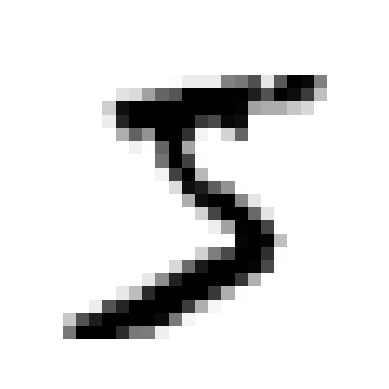

In [5]:
import matplotlib.pyplot as plt
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

# Assuming X is your loaded MNIST data
some_digit = X[0]
plot_digit(some_digit)

plt.savefig("first_mnist_digit.png", dpi=150, bbox_inches="tight", pad_inches=0.1)
print("Digit saved as 'first_mnist_digit.png' — open it now!")
# You can remove or keep plt.show() — it won't hurt, but won't show anything either

In [6]:
y[0]

'5'

Okay, so let us do a feel of classification, but before that we need to split out data into the training(first 60000 images) and test set(last 10000 images):

In [7]:
X_train, X_test,y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

    The trainign set is already shuffled for us, which is good because this guarantees that all cross-validation fols will be similar(we do not want one fold to be missing some digits). Morover some learning algorithms ar sensitive to the order of the training instance, and perform poorly if they gt similar intances in a row. Shuffling the dataset ensures that this won't happen.

Training a Binary Classifier
let us simplify the problem for now and only try to identify one digit-for example the number 5. this "5-detector" will be an example of abinary classifier, capable of distinguishing btw two classes, 5 and non-5. First we create the target vectors for this classification task:

In [8]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

    Now let us picka classifer and train it. a good place to start is with a STOCHASTIC GRADIENT DESCENT(SGD. or stochastic GD) classifier, using SckitLearn's SDGClassifier class. This classifier is capable of handling very lrge datasets efficiently. And deals with training instances independently, one at a time, which also SGD deals well suited for online learning, as you will see later. Let's create an SDGClassifier and train it on the whole training set:

    

In [10]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)

# now using it to predict an image
sgd_clf.predict([some_digit])



array([ True])

PERFORMANCE MEASURES:
Evaluation here is tricker than that of regression.
Measuring Acuuracy Using Cross-Validation:
A good way to evaluate a model is though cross-validation, let us use the cross_val_score() function to evaluate our SGDClassifier model, using kfold cross validation with 3 folds.

In [11]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv = 3, scoring='accuracy')


array([0.95035, 0.96035, 0.9604 ])

We had above 95 percent accuracy to confirm again using DUMMY

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(dummy_clf.predict(X_train)) # prints False when no 5s is available

[False False False ... False False False]


In [14]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring = "accuracy")

array([0.90965, 0.90965, 0.90965])

That’s right, it has over 90% accuracy! This is simply because only about
10% of the images are 5s, so if you always guess that an image is not a 5,
you will be right about 90% of the time. Beats Nostradamus.
This demonstrates why accuracy is generally not the preferred performance
measure for classifiers, especially when you are dealing with skewed
datasets (i.e., when some classes are much more frequent than others). A
much better way to evaluate the performance of a classifier is to look at the
confusion matrix (CM).

CONFUSION MATRIX
The genral idea of a confusion matrix is to count the number of times instances of class A are classified as class B, for all A/B pairs For eaxmple, to now the numbr of times the classifie confused the images of 8 with 0, you would look at row 8, column 0 of the confusion matrix.

To compute the confusion matrix, you first need to have a set of predictions so that they can be compared to the actual targets. You could make predictions on the test set, but it.s best to keep that untouched for now(remember that you ant to use the test set only at the very end of ur project, once you have a classifier that you are ready to launch). Instead, you can use the cross_val_predict() funtions:

In [16]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3)

# it performs kfold but instead of returning evaluation scores, it returns th evaluation scores, it returns the predictions made for each instance in the training set
#Now youare ready to get theconfusion matrix using the confusion_matrix(). Just pass it the target classes.
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

What each cell ctuallly mean
True Positive: Model said Positive- Correctly thought the thing you are looking or

True Neagtive: Model said is Negative and it is really negative

False Positive Positive: Type 1 error Model said Positive, but it is actually Negavtive(False Alarm)

False Negative: Type ii error, Model said Hegative butt it is actually Positive


Here, each row in a confusion matrix represents an actual class, while the each column represents a predicted class. The first row f this matrix considers non-5images(the negative class). 53,892 of them were correctly classified as non-5s(they are called True Negatives), while the remaining 687 were wrongly classifed as 5s(the positive class): 1,891 were wrongly classified as non-5s(false nagatives, also called type ii error), while while the remaining ,530 were correctly lassified as 5s(true positives). A peefct classifier would have only true positives and ture negatives. so its confusion matrix would have nonzero values only on its mian diagonal(top left to butttom right):

CM gives a lot of information, but one of the things to consider important is PRECISION
Precision = TP/(TP+FP)

Atrivial way to have perfect precision is to crate a classifier that always makes negative predictions, escept for one single positive prediction on the instance it is most confident about.If this one prediction is correct, then the
classifier has 100% precision (precision = 1/1 = 100%). Obviously, such a
classifier would not be very useful, since it would ignore all but one
positive instance. So, precision is typically used along with another metric
named recall, also called sensitivity or the true positive rate (TPR): this is
the ratio of positive instances that are correctly detected by the classifier


recall = TP/(TP + FN)

PRECISION AND RECALL

In [22]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)


0.8370879772350012

In [18]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

it is convenient to combine precision and recall into a single metric called the F1 scoe, especially when you need a single metric to compare two classifiers. The F1 scaore is harmonic mean of precision and recall. Whereas the regular mean treats all values equally, the harmonic mean gives more weight to low values. As a result, the classifier will only get a high F1 scaore if both recall and precison are high.

F1 = 2 x (precision x recall)/(precision + recall) = TP/(TP + (FN+FP)/2)

In [24]:
# just call f1_score() to implement
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

The F score favors classifiers that have similar precision and recall. This is
not always what you want: in some contexts you mostly care about
precision, and in other contexts you really care about recall. For example, if
you trained a classifier to detect videos that are safe for kids, you would
probably prefer a classifier that rejects many good videos (low recall) but
keeps only safe ones (high precision), rather than a classifier that has a
much higher recall but lets a few really bad videos show up in your product
(in such cases, you may even want to add a human pipeline to check the
classifier’s video selection). On the other hand, suppose you train a
classifier to detect shoplifters in surveillance images: it is probably fine if
your classifier only has 30% precision as long as it has 99% recall (sure, the
security guards will get a few false alerts, but almost all shoplifters will get
caught).
Unfortunately, you can’t have it both ways: increasing precision reduces
recall, and vice versa. This is called the precision/recall trade-off.

The Precision/Recall Trade-off:

Precison and recall are both about or zoom in to how the model handles the positive class.

Precision is trying to avoid Type i error(False Positive), while Recall is trying to avoid Type II error(False Negative)
